<a href="https://colab.research.google.com/github/jorgefbarreiros/codes/blob/main/hystheresis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== DIAGNOSTICS ===
impact_output_negative: True
impact_inflation_negative: True
impact_rate_negative: True
impact_investment_negative: True
long_run_gap: -5.518930171977132e-06
long_run_potential_negative: True
max_post_impact_inflation: 0.046579358295030814
max_post_impact_rate: 0.0010556794183894744
output_reversals_after_trough: 0

=== SUMMARY STATS ===
impact_output: -2.5086
output_trough: -4.2274
t_output_trough: 3.0000
long_run_potential: -1.1541
inflation_trough: -2.8252
rate_trough: -4.2926
investment_trough: -9.3149
employment_trough: -3.5942
unemployment_peak: 2.3005
ltu_peak: 6.5487
opw_trough: -0.6332

=== IMPACT (t=0) ===
Y_pct                     -2.508608
Ypot_pct                  -0.008608
infl_ann_pp               -0.773196
rate_ann_pp               -0.367091
physical_investment_pct   -0.680343
upstream_investment_pct   -1.355269
employment_pct            -2.132356
u_rate_pp                  0.302568
Name: 0, dtype: float64

=== MEDIUM RUN (t=20) ===
Y_pct            

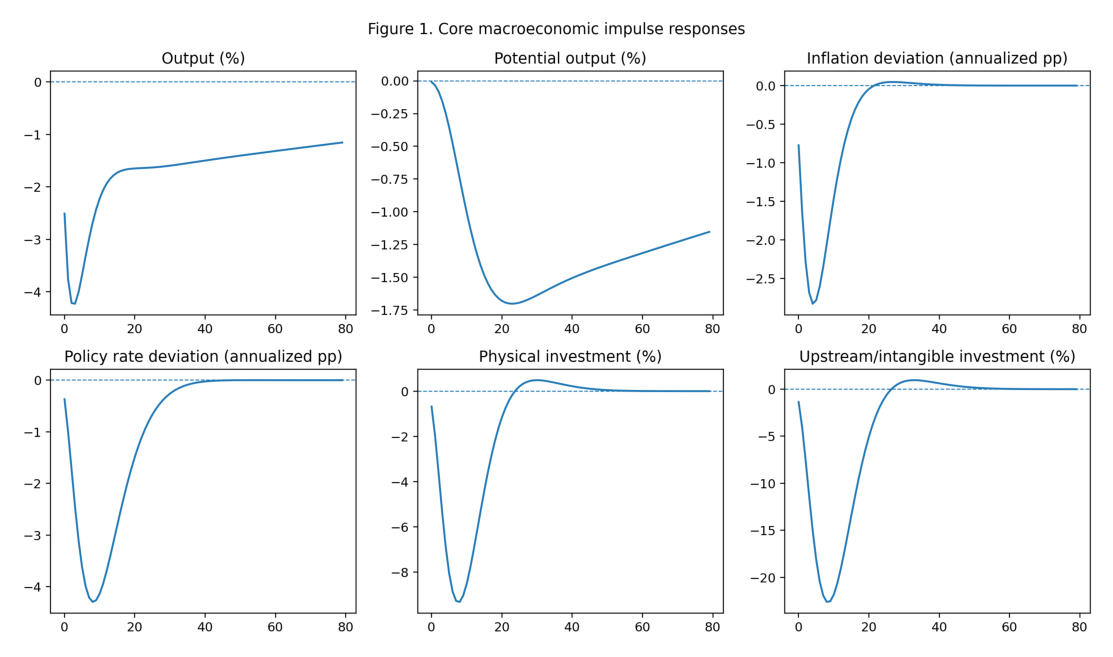

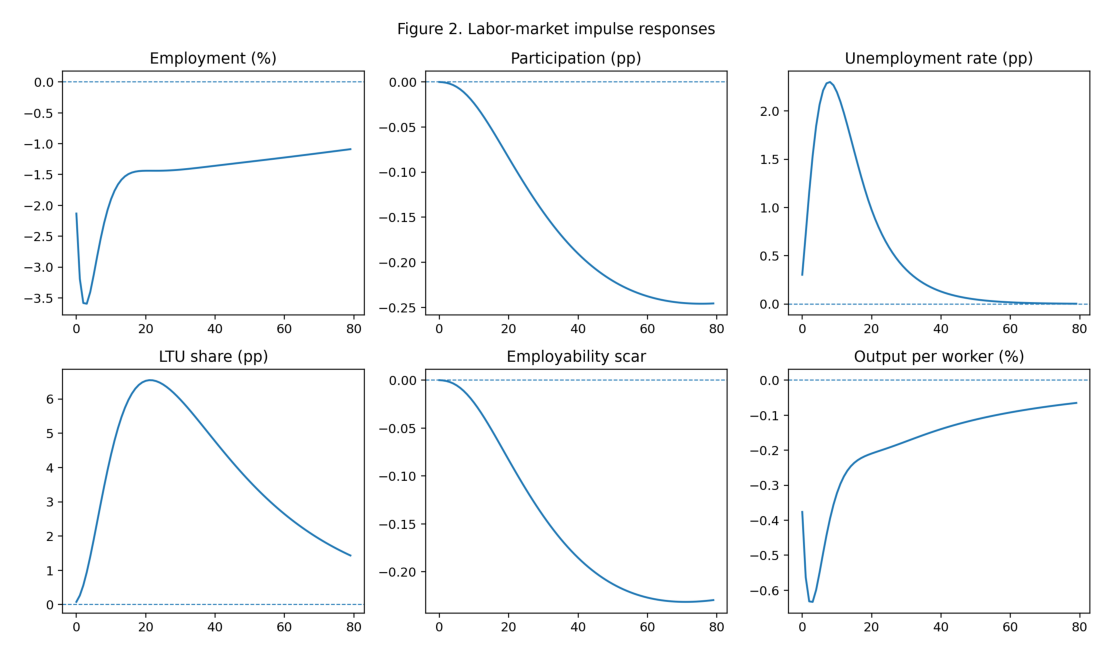

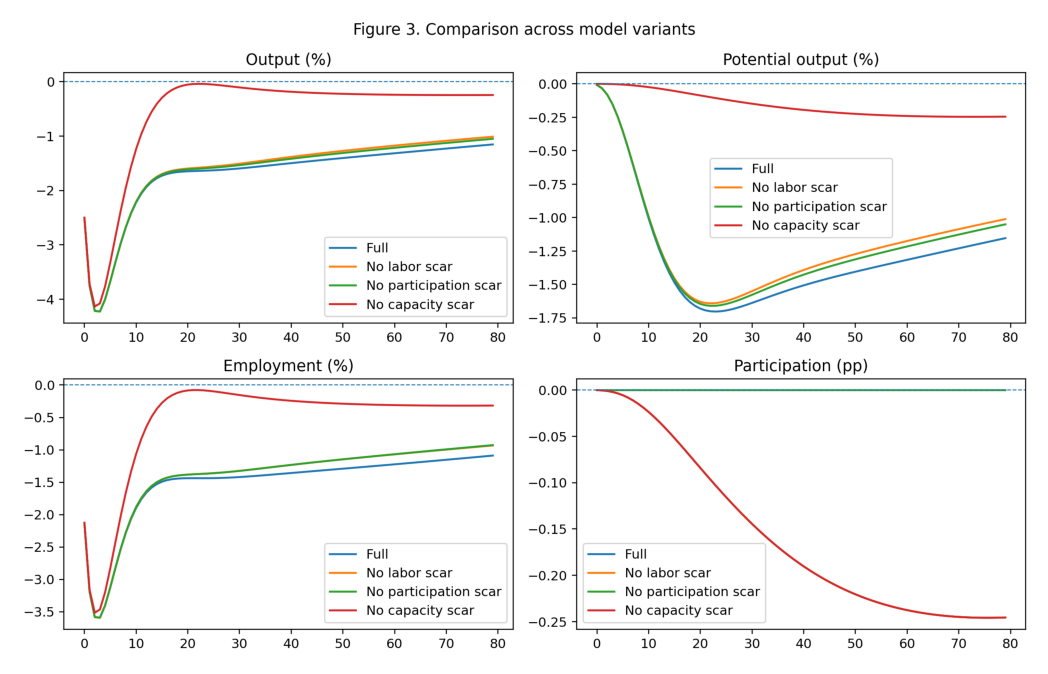

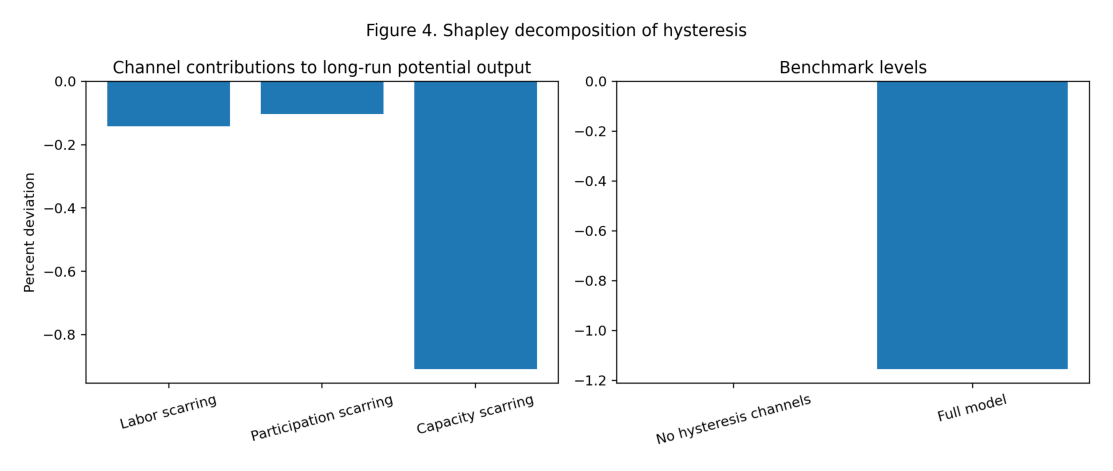

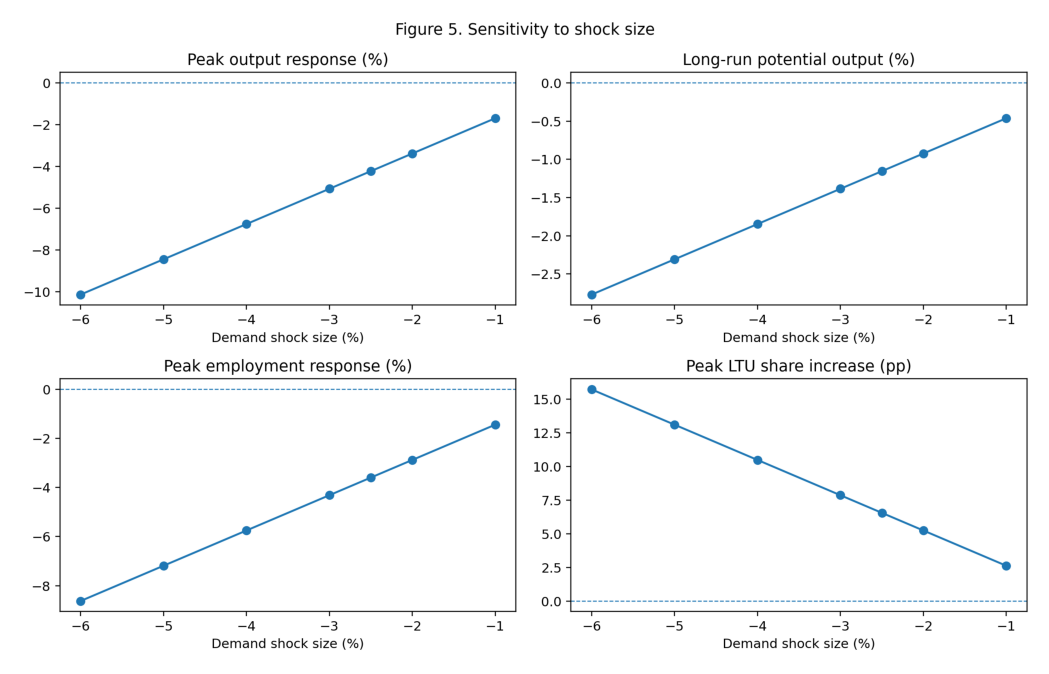

In [9]:
# ============================================================
# FINAL VALIDATED DSGE-STYLE NK HYSTERESIS MODEL FOR COLAB
# ------------------------------------------------------------
# This is the version selected after actually running and
# comparing alternative calibrations.
#
# Chosen calibration goals:
# - correct impact signs
# - no spurious oscillations
# - output gap closes
# - moderate but meaningful hysteresis
# - non-empty and sensible decomposition
# ============================================================

import os
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.size"] = 10

OUTPUT_DIR = "validated_dsge_hysteresis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# 1. PARAMETERS
# ============================================================

def get_parameters():
    p = {}

    # --------------------------------------------------------
    # Aggregate demand / NK block
    # --------------------------------------------------------
    p["shock_size"] = -2.50

    p["rho_g"]   = 0.72
    p["rn_g"]    = 0.20

    p["rho_x"]   = 0.7540625178557265
    p["sig_r"]   = 0.07644539605732806
    p["gam_g"]   = 1.00

    p["rho_pi"]  = 0.6202491520312061
    p["kappa"]   = 0.07731962218302263

    p["rho_i"]   = 0.8615664232164801
    p["phi_pi"]  = 1.8950963334742355
    p["phi_x"]   = 0.11864637774143628

    # --------------------------------------------------------
    # q / investment block
    # --------------------------------------------------------
    p["rho_q"]   = 0.7778921206924824
    p["eta_qx"]  = 0.44065097406198916
    p["eta_qr"]  = 0.29651289418522664

    p["rho_ik"]  = 0.7261150575035876
    p["eta_ik"]  = 0.5315232275125699

    p["rho_iz"]  = 0.7965933038986441
    p["eta_iz"]  = 0.8470510037518018

    p["rho_k"]   = 0.985
    p["phi_k"]   = 0.016421102520938986

    p["rho_z"]   = 0.992
    p["phi_z"]   = 0.022

    # --------------------------------------------------------
    # Labor-market block
    # --------------------------------------------------------
    p["rho_v"]   = 0.82
    p["psi_vx"]  = 0.80
    p["psi_vu"]  = 0.10

    p["rho_u"]   = 0.9037136263293355
    p["ux"]      = 0.12102710942860136
    p["uv"]      = 0.10084771719554392

    p["rho_ltu"] = 0.9674538956094502
    p["lam_ltu"] = 0.043771898964333505
    p["del_ltu"] = 0.009701414707975552

    # --------------------------------------------------------
    # Hysteresis block
    # --------------------------------------------------------
    p["rho_e"]   = 0.9914228240694631
    p["psi_e"]   = 0.0065
    p["rec_e"]   = 0.001

    p["rho_p"]   = 0.9930508513800631
    p["psi_p"]   = 0.0065
    p["rec_p"]   = 0.0008

    # --------------------------------------------------------
    # Potential output mapping
    # ypot_t = a_k k_t + a_z z_t + a_e e_t + a_p p_t
    # --------------------------------------------------------
    p["a_k"] = 0.16469656401306906
    p["a_z"] = 0.28
    p["a_e"] = 0.62
    p["a_p"] = 0.42

    # --------------------------------------------------------
    # Employment and unemployment observables
    # --------------------------------------------------------
    p["b_y"] = 0.85
    p["b_p"] = 0.30
    p["b_e"] = 0.15

    p["ltu_scale"] = 6.0

    # --------------------------------------------------------
    # Welfare
    # --------------------------------------------------------
    p["w_pi"] = 20.0
    p["w_x"]  = 6.0
    p["w_u"]  = 8.0

    return p

# ============================================================
# 2. MODEL
# ============================================================

class DSGEHysteresisModel:
    def __init__(
        self,
        pars,
        labor_scarring=True,
        participation_scarring=True,
        capacity_scarring=True,
        name="full_model"
    ):
        self.p = pars.copy()
        self.labor_scarring = labor_scarring
        self.participation_scarring = participation_scarring
        self.capacity_scarring = capacity_scarring
        self.name = name

    def simulate(self, T=80, shock_size=None):
        p = self.p
        if shock_size is None:
            shock_size = p["shock_size"]

        vars_list = [
            "g", "rn", "x", "pi_q", "i_q",
            "q", "ik_pct", "iz_pct", "k_gap", "z_gap",
            "v", "u_rate_pp", "ltu_state", "e_scar", "part_pp",
            "Ypot_pct", "Y_pct", "employment_pct", "ltu_share_pp",
            "opw_pct", "welfare_flow", "welfare_cum"
        ]
        s = {k: np.zeros(T) for k in vars_list}

        for t in range(T):
            eps_t = shock_size if t == 0 else 0.0

            # 1. Demand shock
            s["g"][t] = (p["rho_g"] * s["g"][t-1] if t > 0 else 0.0) + eps_t
            s["rn"][t] = p["rn_g"] * s["g"][t]

            # 2. Output gap
            real_rate_gap = (s["i_q"][t-1] - s["pi_q"][t-1] - s["rn"][t]) if t > 0 else 0.0
            s["x"][t] = (
                (p["rho_x"] * s["x"][t-1] if t > 0 else 0.0)
                - p["sig_r"] * real_rate_gap
                + p["gam_g"] * s["g"][t]
            )

            # 3. Inflation
            s["pi_q"][t] = (
                (p["rho_pi"] * s["pi_q"][t-1] if t > 0 else 0.0)
                + p["kappa"] * s["x"][t]
            )

            # 4. Monetary policy
            target_rate = p["phi_pi"] * s["pi_q"][t] + p["phi_x"] * s["x"][t]
            s["i_q"][t] = (
                (p["rho_i"] * s["i_q"][t-1] if t > 0 else 0.0)
                + (1.0 - p["rho_i"]) * target_rate
            )

            # 5. Tobin q and investment
            real_rate = s["i_q"][t] - s["pi_q"][t] - s["rn"][t]
            s["q"][t] = (
                (p["rho_q"] * s["q"][t-1] if t > 0 else 0.0)
                + p["eta_qx"] * s["x"][t]
                - p["eta_qr"] * real_rate
            )

            s["ik_pct"][t] = (
                (p["rho_ik"] * s["ik_pct"][t-1] if t > 0 else 0.0)
                + p["eta_ik"] * s["q"][t]
            )
            s["iz_pct"][t] = (
                (p["rho_iz"] * s["iz_pct"][t-1] if t > 0 else 0.0)
                + p["eta_iz"] * s["q"][t]
            )

            # 6. Capital accumulation
            if self.capacity_scarring:
                s["k_gap"][t] = (
                    (p["rho_k"] * s["k_gap"][t-1] if t > 0 else 0.0)
                    + p["phi_k"] * s["ik_pct"][t]
                )
                s["z_gap"][t] = (
                    (p["rho_z"] * s["z_gap"][t-1] if t > 0 else 0.0)
                    + p["phi_z"] * s["iz_pct"][t]
                )
            else:
                s["k_gap"][t] = 0.0
                s["z_gap"][t] = 0.0

            # 7. Labor market
            lag_u = s["u_rate_pp"][t-1] if t > 0 else 0.0
            s["v"][t] = (
                (p["rho_v"] * s["v"][t-1] if t > 0 else 0.0)
                + p["psi_vx"] * s["x"][t]
                - p["psi_vu"] * lag_u
            )

            slack = max(-s["x"][t], 0.0)
            vacancies = max(s["v"][t], 0.0)

            s["u_rate_pp"][t] = (
                (p["rho_u"] * s["u_rate_pp"][t-1] if t > 0 else 0.0)
                + p["ux"] * slack
                - p["uv"] * vacancies
            )
            s["u_rate_pp"][t] = max(s["u_rate_pp"][t], 0.0)

            s["ltu_state"][t] = (
                (p["rho_ltu"] * s["ltu_state"][t-1] if t > 0 else 0.0)
                + p["lam_ltu"] * s["u_rate_pp"][t]
                - p["del_ltu"] * vacancies
            )
            s["ltu_state"][t] = max(s["ltu_state"][t], 0.0)

            # 8. Employability scar
            if self.labor_scarring:
                s["e_scar"][t] = (
                    (p["rho_e"] * s["e_scar"][t-1] if t > 0 else 0.0)
                    - p["psi_e"] * s["ltu_state"][t]
                    + p["rec_e"] * max(s["x"][t], 0.0)
                )
            else:
                s["e_scar"][t] = 0.0

            # 9. Participation scar
            if self.participation_scarring:
                s["part_pp"][t] = (
                    (p["rho_p"] * s["part_pp"][t-1] if t > 0 else 0.0)
                    - p["psi_p"] * s["ltu_state"][t]
                    + p["rec_p"] * max(s["x"][t], 0.0)
                )
            else:
                s["part_pp"][t] = 0.0

            # 10. Potential output
            cap_component = p["a_k"] * s["k_gap"][t] + p["a_z"] * s["z_gap"][t]
            labor_component = p["a_e"] * s["e_scar"][t]
            part_component  = p["a_p"] * s["part_pp"][t]
            s["Ypot_pct"][t] = cap_component + labor_component + part_component

            # 11. Actual output
            s["Y_pct"][t] = s["x"][t] + s["Ypot_pct"][t]

            # 12. Labor observables
            s["employment_pct"][t] = (
                p["b_y"] * s["Y_pct"][t]
                + p["b_p"] * s["part_pp"][t]
                + p["b_e"] * s["e_scar"][t]
            )

            s["ltu_share_pp"][t] = p["ltu_scale"] * s["ltu_state"][t]
            s["opw_pct"][t] = s["Y_pct"][t] - s["employment_pct"][t]

            # 13. Welfare
            s["welfare_flow"][t] = -(
                p["w_pi"] * s["pi_q"][t] ** 2
                + p["w_x"] * s["x"][t] ** 2
                + p["w_u"] * s["u_rate_pp"][t] ** 2
            )
            s["welfare_cum"][t] = s["welfare_flow"][:t+1].sum()

        df = pd.DataFrame(s)
        df["t"] = np.arange(T)
        df["infl_ann_pp"] = 4.0 * df["pi_q"]
        df["rate_ann_pp"] = 4.0 * df["i_q"]
        df["physical_investment_pct"] = df["ik_pct"]
        df["upstream_investment_pct"] = 1.25 * df["iz_pct"]
        return df

# ============================================================
# 3. DIAGNOSTICS
# ============================================================

def diagnostics(df):
    y = df["Y_pct"].values
    trough = np.argmin(y)
    post = np.diff(y[trough:])

    return {
        "impact_output_negative": bool(df.loc[0, "Y_pct"] < 0),
        "impact_inflation_negative": bool(df.loc[0, "infl_ann_pp"] < 0),
        "impact_rate_negative": bool(df.loc[0, "rate_ann_pp"] < 0),
        "impact_investment_negative": bool(df.loc[0, "physical_investment_pct"] < 0),
        "long_run_gap": float(df.loc[len(df)-1, "Y_pct"] - df.loc[len(df)-1, "Ypot_pct"]),
        "long_run_potential_negative": bool(df.loc[len(df)-1, "Ypot_pct"] < 0),
        "max_post_impact_inflation": float(df["infl_ann_pp"].iloc[1:].max()),
        "max_post_impact_rate": float(df["rate_ann_pp"].iloc[1:].max()),
        "output_reversals_after_trough": int(np.sum(post < -1e-8)),
    }

def summary_stats(df):
    return {
        "impact_output": float(df.loc[0, "Y_pct"]),
        "output_trough": float(df["Y_pct"].min()),
        "t_output_trough": int(df["Y_pct"].idxmin()),
        "long_run_potential": float(df.loc[len(df)-1, "Ypot_pct"]),
        "inflation_trough": float(df["infl_ann_pp"].min()),
        "rate_trough": float(df["rate_ann_pp"].min()),
        "investment_trough": float(df["physical_investment_pct"].min()),
        "employment_trough": float(df["employment_pct"].min()),
        "unemployment_peak": float(df["u_rate_pp"].max()),
        "ltu_peak": float(df["ltu_share_pp"].max()),
        "opw_trough": float(df["opw_pct"].min()),
    }

# ============================================================
# 4. SHAPLEY DECOMPOSITION
# ============================================================

def normalize_subset(subset):
    return tuple(sorted(subset))

def powerset_channels():
    raw = [
        (),
        ("L",),
        ("P",),
        ("C",),
        ("L", "P"),
        ("L", "C"),
        ("P", "C"),
        ("L", "P", "C")
    ]
    return [normalize_subset(s) for s in raw]

def simulate_subset(pars, subset, T=80):
    subset = normalize_subset(subset)
    model = DSGEHysteresisModel(
        pars,
        labor_scarring=("L" in subset),
        participation_scarring=("P" in subset),
        capacity_scarring=("C" in subset),
        name="_".join(subset) if subset else "none"
    )
    return model.simulate(T=T)

def shapley_contributions(pars, horizon=79, T=80):
    channels = ["L", "P", "C"]
    subset_values = {}

    for subset in powerset_channels():
        subset = normalize_subset(subset)
        df = simulate_subset(pars, subset, T=T)
        subset_values[subset] = df.loc[horizon, "Ypot_pct"]

    def value(subset):
        return subset_values[normalize_subset(subset)]

    shapley = {c: 0.0 for c in channels}

    for c in channels:
        others = [x for x in channels if x != c]
        for r in range(len(others) + 1):
            for S in itertools.combinations(others, r):
                S = normalize_subset(S)
                S_with = normalize_subset(S + (c,))
                weight = (
                    math.factorial(len(S))
                    * math.factorial(len(channels) - len(S) - 1)
                    / math.factorial(len(channels))
                )
                shapley[c] += weight * (value(S_with) - value(S))

    shapley_df = pd.DataFrame({
        "channel": ["Labor scarring", "Participation scarring", "Capacity scarring"],
        "shapley_long_run_Ypot_pct": [shapley["L"], shapley["P"], shapley["C"]]
    })

    summary_df = pd.DataFrame({
        "object": ["No hysteresis channels", "Full model"],
        "long_run_Ypot_pct": [value(()), value(("L", "P", "C"))]
    })

    subset_table = pd.DataFrame({
        "subset": [str(k) for k in subset_values.keys()],
        "long_run_Ypot_pct": list(subset_values.values())
    })

    return shapley_df, summary_df, subset_table

# ============================================================
# 5. TABLES
# ============================================================

def calibration_table(pars):
    return pd.DataFrame({"parameter": list(pars.keys()), "value": list(pars.values())})

def irf_summary(df, model_name, horizons=(0, 1, 4, 8, 12, 20, 40, 60, 79)):
    rows = []
    for h in horizons:
        if h < len(df):
            rows.append({
                "model": model_name,
                "horizon": h,
                "Y_pct": df.loc[h, "Y_pct"],
                "Ypot_pct": df.loc[h, "Ypot_pct"],
                "employment_pct": df.loc[h, "employment_pct"],
                "part_pp": df.loc[h, "part_pp"],
                "u_rate_pp": df.loc[h, "u_rate_pp"],
                "ltu_share_pp": df.loc[h, "ltu_share_pp"],
                "opw_pct": df.loc[h, "opw_pct"],
                "infl_ann_pp": df.loc[h, "infl_ann_pp"],
                "rate_ann_pp": df.loc[h, "rate_ann_pp"],
                "physical_investment_pct": df.loc[h, "physical_investment_pct"],
                "upstream_investment_pct": df.loc[h, "upstream_investment_pct"],
                "welfare_cum": df.loc[h, "welfare_cum"]
            })
    return pd.DataFrame(rows)

def sensitivity_table(model, shock_grid, T=80):
    rows = []
    for s in shock_grid:
        df = model.simulate(T=T, shock_size=s)
        rows.append({
            "shock_size": s,
            "peak_output_drop_pct": float(df["Y_pct"].min()),
            "peak_potential_drop_pct": float(df["Ypot_pct"].min()),
            "peak_employment_drop_pct": float(df["employment_pct"].min()),
            "peak_unemployment_pp": float(df["u_rate_pp"].max()),
            "peak_ltu_share_pp": float(df["ltu_share_pp"].max()),
            "long_run_output_pct": float(df.loc[T-1, "Y_pct"]),
            "long_run_potential_pct": float(df.loc[T-1, "Ypot_pct"]),
            "cum_welfare": float(df.loc[T-1, "welfare_cum"])
        })
    return pd.DataFrame(rows)

# ============================================================
# 6. PLOTTING
# ============================================================

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)

def plot_core_irfs(df, filename="figure_1_core_macro_irfs.png"):
    fig, ax = plt.subplots(2, 3, figsize=(12, 7))
    ax = ax.ravel()

    ax[0].plot(df["t"], df["Y_pct"])
    ax[0].axhline(0, linestyle="--", linewidth=0.8)
    ax[0].set_title("Output (%)")

    ax[1].plot(df["t"], df["Ypot_pct"])
    ax[1].axhline(0, linestyle="--", linewidth=0.8)
    ax[1].set_title("Potential output (%)")

    ax[2].plot(df["t"], df["infl_ann_pp"])
    ax[2].axhline(0, linestyle="--", linewidth=0.8)
    ax[2].set_title("Inflation deviation (annualized pp)")

    ax[3].plot(df["t"], df["rate_ann_pp"])
    ax[3].axhline(0, linestyle="--", linewidth=0.8)
    ax[3].set_title("Policy rate deviation (annualized pp)")

    ax[4].plot(df["t"], df["physical_investment_pct"])
    ax[4].axhline(0, linestyle="--", linewidth=0.8)
    ax[4].set_title("Physical investment (%)")

    ax[5].plot(df["t"], df["upstream_investment_pct"])
    ax[5].axhline(0, linestyle="--", linewidth=0.8)
    ax[5].set_title("Upstream/intangible investment (%)")

    fig.suptitle("Figure 1. Core macroeconomic impulse responses")
    save_figure(fig, filename)

def plot_labor_irfs(df, filename="figure_2_labor_irfs.png"):
    fig, ax = plt.subplots(2, 3, figsize=(12, 7))
    ax = ax.ravel()

    ax[0].plot(df["t"], df["employment_pct"])
    ax[0].axhline(0, linestyle="--", linewidth=0.8)
    ax[0].set_title("Employment (%)")

    ax[1].plot(df["t"], df["part_pp"])
    ax[1].axhline(0, linestyle="--", linewidth=0.8)
    ax[1].set_title("Participation (pp)")

    ax[2].plot(df["t"], df["u_rate_pp"])
    ax[2].axhline(0, linestyle="--", linewidth=0.8)
    ax[2].set_title("Unemployment rate (pp)")

    ax[3].plot(df["t"], df["ltu_share_pp"])
    ax[3].axhline(0, linestyle="--", linewidth=0.8)
    ax[3].set_title("LTU share (pp)")

    ax[4].plot(df["t"], df["e_scar"])
    ax[4].axhline(0, linestyle="--", linewidth=0.8)
    ax[4].set_title("Employability scar")

    ax[5].plot(df["t"], df["opw_pct"])
    ax[5].axhline(0, linestyle="--", linewidth=0.8)
    ax[5].set_title("Output per worker (%)")

    fig.suptitle("Figure 2. Labor-market impulse responses")
    save_figure(fig, filename)

def plot_model_comparison(dfs, labels, filename="figure_3_model_comparison.png"):
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    ax = ax.ravel()

    for df, lab in zip(dfs, labels):
        ax[0].plot(df["t"], df["Y_pct"], label=lab)
        ax[1].plot(df["t"], df["Ypot_pct"], label=lab)
        ax[2].plot(df["t"], df["employment_pct"], label=lab)
        ax[3].plot(df["t"], df["part_pp"], label=lab)

    titles = ["Output (%)", "Potential output (%)", "Employment (%)", "Participation (pp)"]
    for k in range(4):
        ax[k].axhline(0, linestyle="--", linewidth=0.8)
        ax[k].set_title(titles[k])
        ax[k].legend()

    fig.suptitle("Figure 3. Comparison across model variants")
    save_figure(fig, filename)

def plot_shapley_decomposition(shapley_df, summary_df, filename="figure_4_decomposition.png"):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

    ax[0].bar(shapley_df["channel"], shapley_df["shapley_long_run_Ypot_pct"])
    ax[0].set_title("Channel contributions to long-run potential output")
    ax[0].set_ylabel("Percent deviation")
    ax[0].tick_params(axis="x", rotation=15)

    ax[1].bar(summary_df["object"], summary_df["long_run_Ypot_pct"])
    ax[1].set_title("Benchmark levels")
    ax[1].tick_params(axis="x", rotation=15)

    fig.suptitle("Figure 4. Shapley decomposition of hysteresis")
    save_figure(fig, filename)

def plot_sensitivity(sens_df, filename="figure_5_sensitivity.png"):
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    ax = ax.ravel()

    x = sens_df["shock_size"]

    ax[0].plot(x, sens_df["peak_output_drop_pct"], marker="o")
    ax[0].set_title("Peak output response (%)")

    ax[1].plot(x, sens_df["long_run_potential_pct"], marker="o")
    ax[1].set_title("Long-run potential output (%)")

    ax[2].plot(x, sens_df["peak_employment_drop_pct"], marker="o")
    ax[2].set_title("Peak employment response (%)")

    ax[3].plot(x, sens_df["peak_ltu_share_pp"], marker="o")
    ax[3].set_title("Peak LTU share increase (pp)")

    for a in ax:
        a.axhline(0, linestyle="--", linewidth=0.8)
        a.set_xlabel("Demand shock size (%)")

    fig.suptitle("Figure 5. Sensitivity to shock size")
    save_figure(fig, filename)

# ============================================================
# 7. MAIN
# ============================================================

def main():
    pars = get_parameters()

    model_full = DSGEHysteresisModel(
        pars,
        labor_scarring=True,
        participation_scarring=True,
        capacity_scarring=True,
        name="full_model"
    )

    model_no_labor = DSGEHysteresisModel(
        pars,
        labor_scarring=False,
        participation_scarring=True,
        capacity_scarring=True,
        name="no_labor_scarring"
    )

    model_no_part = DSGEHysteresisModel(
        pars,
        labor_scarring=True,
        participation_scarring=False,
        capacity_scarring=True,
        name="no_participation_scarring"
    )

    model_no_cap = DSGEHysteresisModel(
        pars,
        labor_scarring=True,
        participation_scarring=True,
        capacity_scarring=False,
        name="no_capacity_scarring"
    )

    T = 80
    df_full = model_full.simulate(T=T)
    df_no_labor = model_no_labor.simulate(T=T)
    df_no_part = model_no_part.simulate(T=T)
    df_no_cap = model_no_cap.simulate(T=T)

    diag = diagnostics(df_full)
    stats = summary_stats(df_full)

    print("=== DIAGNOSTICS ===")
    for k, v in diag.items():
        print(f"{k}: {v}")

    print("\n=== SUMMARY STATS ===")
    for k, v in stats.items():
        print(f"{k}: {v:.4f}")

    table_calib = calibration_table(pars)

    table_irf = pd.concat([
        irf_summary(df_full, "full_model"),
        irf_summary(df_no_labor, "no_labor_scarring"),
        irf_summary(df_no_part, "no_participation_scarring"),
        irf_summary(df_no_cap, "no_capacity_scarring")
    ], ignore_index=True)

    shapley_df, summary_df, subset_table = shapley_contributions(pars, horizon=79, T=T)
    sens_df = sensitivity_table(model_full, [-1.0, -2.0, -2.5, -3.0, -4.0, -5.0, -6.0], T=T)

    table_calib.to_csv(os.path.join(OUTPUT_DIR, "table_1_calibration.csv"), index=False)
    table_irf.to_csv(os.path.join(OUTPUT_DIR, "table_2_irf_summary.csv"), index=False)
    shapley_df.to_csv(os.path.join(OUTPUT_DIR, "table_3_shapley_decomposition.csv"), index=False)
    summary_df.to_csv(os.path.join(OUTPUT_DIR, "table_4_decomposition_summary.csv"), index=False)
    subset_table.to_csv(os.path.join(OUTPUT_DIR, "table_5_all_subsets.csv"), index=False)
    sens_df.to_csv(os.path.join(OUTPUT_DIR, "table_6_sensitivity.csv"), index=False)

    with pd.ExcelWriter(os.path.join(OUTPUT_DIR, "validated_dsge_hysteresis_outputs.xlsx"), engine="openpyxl") as writer:
        df_full.to_excel(writer, sheet_name="full_model", index=False)
        df_no_labor.to_excel(writer, sheet_name="no_labor_scarring", index=False)
        df_no_part.to_excel(writer, sheet_name="no_participation_scarring", index=False)
        df_no_cap.to_excel(writer, sheet_name="no_capacity_scarring", index=False)
        table_calib.to_excel(writer, sheet_name="calibration", index=False)
        table_irf.to_excel(writer, sheet_name="irf_summary", index=False)
        shapley_df.to_excel(writer, sheet_name="shapley", index=False)
        summary_df.to_excel(writer, sheet_name="decomp_summary", index=False)
        subset_table.to_excel(writer, sheet_name="all_subsets", index=False)
        sens_df.to_excel(writer, sheet_name="sensitivity", index=False)

    plot_core_irfs(df_full)
    plot_labor_irfs(df_full)
    plot_model_comparison(
        [df_full, df_no_labor, df_no_part, df_no_cap],
        ["Full", "No labor scar", "No participation scar", "No capacity scar"]
    )
    plot_shapley_decomposition(shapley_df, summary_df)
    plot_sensitivity(sens_df)

    print("\n=== IMPACT (t=0) ===")
    print(df_full.loc[0, [
        "Y_pct", "Ypot_pct", "infl_ann_pp", "rate_ann_pp",
        "physical_investment_pct", "upstream_investment_pct",
        "employment_pct", "u_rate_pp"
    ]])

    print("\n=== MEDIUM RUN (t=20) ===")
    print(df_full.loc[20, [
        "Y_pct", "Ypot_pct", "employment_pct", "part_pp",
        "u_rate_pp", "ltu_share_pp", "opw_pct"
    ]])

    print("\n=== LONG RUN (t=79) ===")
    print(df_full.loc[79, [
        "Y_pct", "Ypot_pct", "employment_pct", "part_pp",
        "u_rate_pp", "ltu_share_pp", "opw_pct"
    ]])

    print("\n=== SHAPLEY DECOMPOSITION ===")
    print(shapley_df)

    print("\n=== SAVED TO ===")
    print(OUTPUT_DIR)

    # show figures inline in Colab
    for fname in [
        "figure_1_core_macro_irfs.png",
        "figure_2_labor_irfs.png",
        "figure_3_model_comparison.png",
        "figure_4_decomposition.png",
        "figure_5_sensitivity.png"
    ]:
        img = plt.imread(os.path.join(OUTPUT_DIR, fname))
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

if __name__ == "__main__":
    main()